In [1]:
import json
import os
import pathlib
import sys

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sys.path.insert(0, str(pathlib.PurePath('..')))

In [4]:
import linear_geodesic_optimization.driver as driver

In [5]:
data_dir = pathlib.PurePath('..', '..', 'data')
output_dir = pathlib.PurePath('..', '..', 'outputs')
config_file = data_dir / 'toy' / 'routing_with_volumes' / 'config' / 'traffic_two_clusters.json'

arguments, settings, defaults = driver.load_config(config_file)

output_format = driver.get_output_format(settings, defaults)
driver.assign_output_directories(arguments, settings, output_format, output_directory=output_dir, existence_check='must_exist')

initialization = driver.get_initialization(settings)

In [6]:
ignored_filenames = {
    'output.json',
    'animation.json'
}

losses = []
for argument_set in arguments[0]:
    losses_i = {}
    lambda_smooth = argument_set['lambda_smooth']
    argument_directory_output = pathlib.PurePath(argument_set['directory_output'])
    for filename in sorted(os.listdir(argument_directory_output)):
        if filename in ignored_filenames:
            continue
        filepath = argument_directory_output / filename
        iteration = int(filepath.stem)
        with open(filepath, 'r') as f:
            output = json.load(f)
            loss_curvature = output['L_curvature']
            loss_smooth = output['L_smooth']
            losses_i[iteration] = {
                'L_curvature': loss_curvature,
                'L_smooth': loss_smooth,
                'L_total': loss_curvature + lambda_smooth * loss_smooth,
            }
    losses.append(losses_i)

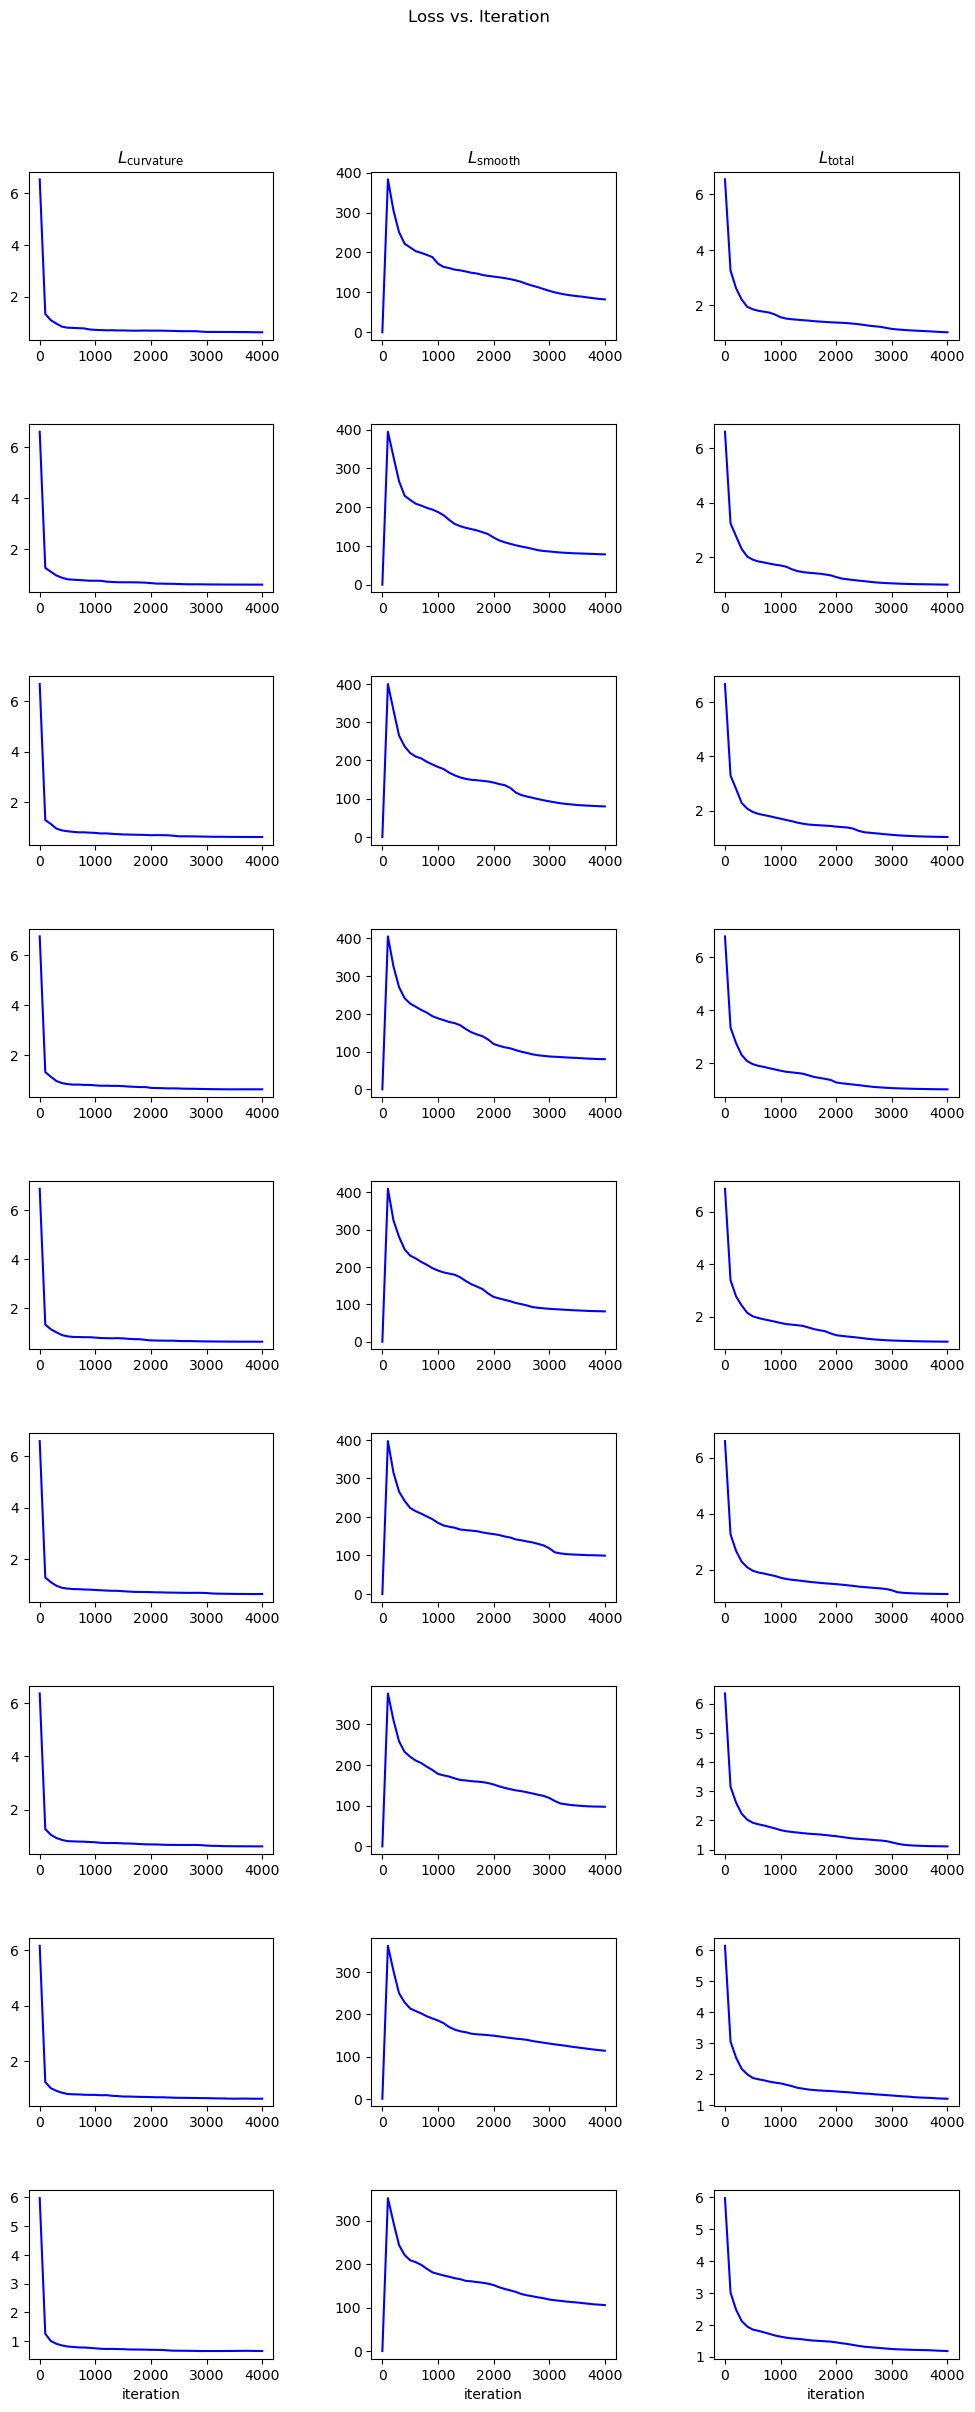

In [7]:
fig, axs = plt.subplots(len(losses), 3, figsize=(12, 3 * len(losses)))
axs = np.atleast_2d(axs)
fig.suptitle("Loss vs. Iteration")
for col, title in enumerate([r"$L_{\text{curvature}}$", r"$L_{\text{smooth}}$", r"$L_{\text{total}}$"]):
    axs[0][col].set_title(title)
for losses_i, axs_i in zip(losses, axs):
    x = list(sorted(losses_i.keys()))
    y_curvature = [losses_i[xj]['L_curvature'] for xj in x]
    y_smooth = [losses_i[xj]['L_smooth'] for xj in x]
    y_total = [losses_i[xj]['L_total'] for xj in x]
    axs_i[0].plot(x, y_curvature, 'b-')
    axs_i[1].plot(x, y_smooth, 'b-')
    axs_i[2].plot(x, y_total, 'b-')
for ax in axs[-1]:
    ax.set_xlabel("iteration")
fig.subplots_adjust(hspace=0.5, wspace=0.4, top=0.92)
plt.show()

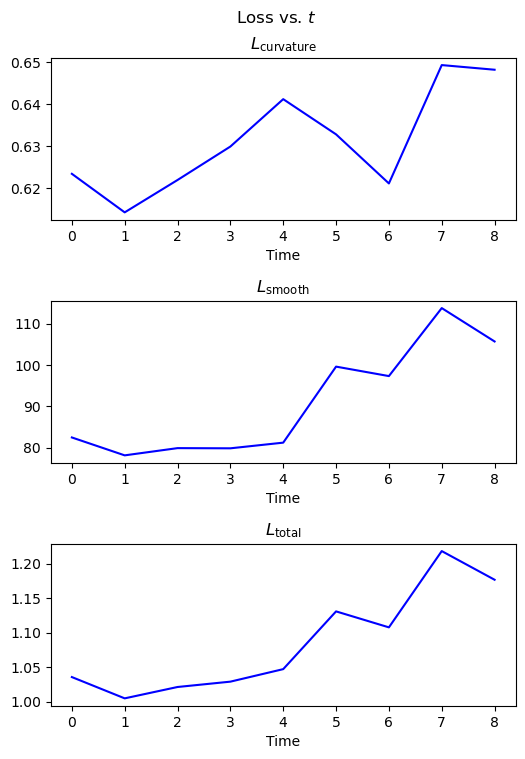

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8))
fig.suptitle(r"Loss vs. $t$")
for ax, title in zip(axs, [r"$L_{\text{curvature}}$", r"$L_{\text{smooth}}$", r"$L_{\text{total}}$"]):
    ax.set_title(title)
    ax.set_xlabel("Time")
for ax, key in zip(axs, ['L_curvature', 'L_smooth', 'L_total']):
    ax.plot(list(range(len(losses))), [losses_i[max(losses_i.keys())][key] for losses_i in losses], 'b-')
fig.subplots_adjust(hspace=0.5, wspace=0.4, top=0.92)
plt.show()